In [1]:
import pandas as pd
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, recall_score, precision_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers = pd.read_csv('olist_customers_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
order_payments = pd.read_csv('olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
product_category_name = pd.read_csv('product_category_name_translation.csv')

# Data Exploration

In [3]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


The customers table above shows two customer IDs. One of them, the one named `customer_id`, is the ID assigned to each customer when they place an order; it can be different for the same customer even if they place the order again, whereas `customer_unique_id`is unique to each customer. 

There are no null values in any column of the customer dataset. 

In [5]:
#orders
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [7]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

We saw null values in the columns: `order_approved_at`, `order_delivered_carrier_date`, and `order_delivered_customer_date`. Maybe the order was cancelled by the customer or the company, and we'll see that in our analysis below.

In [8]:
#order_items
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [9]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


This table holds one row per item within an order: product, seller, price, freight, and shipping deadline. No null values were found in any column.

In [10]:
#order_payments
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [11]:
order_payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


This table records the payment method, the number of installments, and the value per order. No null values were found in any column.

In [12]:
#order_reviews
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [13]:
order_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


In [14]:
order_reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

Many people left the review_comment_title and review_comment_message sections blank. We will see in our analysis whether their corresponding review scores were bad; if so, then the company can ensure that each customer fills them out in the future.

In [15]:
#products
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [16]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [17]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

610 products are missing category name and description info; these rows can't be used in category-level analysis unless we label them 'unknown'. Weight/dimension nulls (2 rows) are negligible and can likely just be dropped.

In [18]:
#sellers
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [19]:
sellers.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


There are a total of 3095 sellers available on Olist. 

In [20]:
#product_category_name
product_category_name.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


A small lookup table mapping Portuguese category names to their English translations, used later to make category labels readable.

### Data Cleaning

Circling back to our question, our analysis needs to identify which variables are contributing to supply chain inefficiencies, and our `orders` dataset will help us narrow down the reasons.

Since our `orders` dataset includes some null values in the `order_delivered_customer_date`, which is an important aspect of our analysis, let's check where these null values exist corresponding to `order_status`.

In [21]:
orders.groupby('order_status')[['order_approved_at','order_delivered_carrier_date','order_delivered_customer_date']].apply(lambda x: x.isnull().sum())

,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
order_status,,,
approved,0,2,2
canceled,141,550,619
created,5,5,5
delivered,14,2,8
invoiced,0,314,314
processing,0,301,301
shipped,0,0,1107
unavailable,0,609,609


As we can see, the null values are distributed across the three columns we saw earlier. For `order_status`, it seems that there are null values in `order_delivered_customer_date` for all `order_status` values, but the biggest concern is the `delivered` status, which has 8 null values. 

In [22]:
orders[(orders['order_status']=='delivered') & (orders['order_delivered_customer_date'].isnull())]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaN,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaN,2018-07-19 00:00:00


While checking null values across order statuses, we found 8 orders marked as `order_status` = `delivered`
that were missing an `order_delivered_customer_date`. This is a contradiction, as an order can't be genuinely 
"delivered" without a recorded delivery date, so these rows are a data quality issue rather than a real 
business case (unlike other statuses such as "canceled" or "processing", where a missing delivery date is 
expected).

Since our core analysis depends on calculating delivery time using `order_delivered_customer_date`, these 
8 rows can't be used regardless of what we decide, and they're a negligible fraction of the dataset 
(~100,000+ total orders). We're dropping them from the working `orders` table.

In [23]:
orders = orders[~((orders['order_status']=='delivered') & (orders['order_delivered_customer_date'].isnull()))]
orders.shape

(99433, 8)

Dropped the 8 contradictory rows; the row count confirms exactly 8 fewer orders than before.

Another contradiction arrives at the`approval` status where 2 nulls are shown in the `order_delivered_customer_date`. However, there remains confusion about how the `approved` status has delivery dates and whether there are more rows that, in fact, do have delivery dates. 

In [24]:
orders[(orders['order_status']=='approved') & (orders['order_delivered_customer_date'].notnull())]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date


In [25]:
orders['order_status'].value_counts()

order_status
delivered      96470
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

We can gather from the above that there are indeed only two rows of `approved` status in our dataset, and it makes sense not to have a delivery date, as an `approved` could not have been delivered, like in the cases of `canceled`, `processing`, and other non-delivered statuses. So no contradiction here.

In [26]:
orders[(orders['order_status']=='canceled') & (orders['order_delivered_customer_date'].notnull())]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
2921,1950d777989f6a877539f53795b4c3c3,1bccb206de9f0f25adc6871a1bcf77b2,canceled,2018-02-19 19:48:52,2018-02-19 20:56:05,2018-02-20 19:57:13,2018-03-21 22:03:51,2018-03-09 00:00:00
8791,dabf2b0e35b423f94618bf965fcb7514,5cdec0bb8cbdf53ffc8fdc212cd247c6,canceled,2016-10-09 00:56:52,2016-10-09 13:36:58,2016-10-13 13:36:59,2016-10-16 14:36:59,2016-11-30 00:00:00
58266,770d331c84e5b214bd9dc70a10b829d0,6c57e6119369185e575b36712766b0ef,canceled,2016-10-07 14:52:30,2016-10-07 15:07:10,2016-10-11 15:07:11,2016-10-14 15:07:11,2016-11-29 00:00:00
59332,8beb59392e21af5eb9547ae1a9938d06,bf609b5741f71697f65ce3852c5d2623,canceled,2016-10-08 20:17:50,2016-10-09 14:34:30,2016-10-14 22:45:26,2016-10-19 18:47:43,2016-11-30 00:00:00
92636,65d1e226dfaeb8cdc42f665422522d14,70fc57eeae292675927697fe03ad3ff5,canceled,2016-10-03 21:01:41,2016-10-04 10:18:57,2016-10-25 12:14:28,2016-11-08 10:58:34,2016-11-25 00:00:00
94399,2c45c33d2f9cb8ff8b1c86cc28c11c30,de4caa97afa80c8eeac2ff4c8da5b72e,canceled,2016-10-09 15:39:56,2016-10-10 10:40:49,2016-10-14 10:40:50,2016-11-09 14:53:50,2016-12-08 00:00:00


While checking the `value_counts` of all the statuses, I noticed `canceled` orders were 625, while the null values of delivery dates were 619. While it makes sense to have null values in `canceled` status, it doesn't make sense to have delivery dates for them. This creates another contradiction. Since these 6 rows have approved dates, carrier dates, and delivered dates, this means that the order was, in fact, delivered but later canceled due to a customer return, refund request, or a dispute. 

Later, in our analysis stage, we'll further evaluate the reviews not just for late deliveries but whether the order was later `canceled`. This clearly shows we can't rely on `delivered` status alone to evaluate our question. The remaining statuses' null counts matched expectations, with no further contradictions found.

In [27]:
print("Duplicated orders: ", orders.duplicated().sum())
print("Duplicated order items: ",order_items.duplicated().sum())
print("Duplicated order reviews: ",order_reviews.duplicated().sum())
print("Duplicated order payments: ",order_payments.duplicated().sum())
print("Duplicated sellers: ",sellers.duplicated().sum())
print("Duplicated products: ",products.duplicated().sum())
print("Duplicated customers: ",customers.duplicated().sum())
print("Duplicated product category name: ",product_category_name.duplicated().sum())

Duplicated orders:  0
Duplicated order items:  0
Duplicated order reviews:  0
Duplicated order payments:  0
Duplicated sellers:  0
Duplicated products:  0
Duplicated customers:  0
Duplicated product category name:  0


Confirmed zero duplicate rows across all 8 tables; no cleaning needed here.

In [28]:
date_columns = [ 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

for col in date_columns:
    orders[col]= pd.to_datetime(orders[col])

orders.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

Converted all order timestamp columns from text to actual datetime type, enabling date-based calculations like delivery time.

In [29]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1782
order_delivered_customer_date    2957
order_estimated_delivery_date       0
dtype: int64

Null counts match expectations after conversion; missing dates are now properly stored as NaT instead of blank text.

In [30]:
review_dates=['review_creation_date', 'review_answer_timestamp']

for col in review_dates:
    order_reviews[col] = pd.to_datetime(order_reviews[col])

order_reviews.dtypes

review_id                             str
order_id                              str
review_score                        int64
review_comment_title                  str
review_comment_message                str
review_creation_date       datetime64[us]
review_answer_timestamp    datetime64[us]
dtype: object

Converted the two review date columns to datetime for consistency and future date-based analysis.

In [31]:
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

order_items.dtypes

order_id                          str
order_item_id                   int64
product_id                        str
seller_id                         str
shipping_limit_date    datetime64[us]
price                         float64
freight_value                 float64
dtype: object

Converted shipping_limit_date to datetime as well.

To continue data cleaning, we'll check for outliers across the numeric columns most relevant to our analysis: price, freight, product dimensions, and payment values.

In [32]:
order_items[['price','freight_value']].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


We can see that `price` and `freight_value` both have maximum values that show a massive jump compared to the mean and the 75% value. Other than that, `freight_value` having a minimum value 0 is not possible.  

In [33]:
order_items[order_items['price']== order_items['price'].max()]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
3556,0812eb902a67711a1cb742b3cdaa65ae,1,489ae2aa008f021502940f251d4cce7f,e3b4998c7a498169dc7bce44e6bb6277,2017-02-16 20:37:36,6735.0,194.31


In [34]:
order_items.sort_values('price', ascending=False).head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
3556,0812eb902a67711a1cb742b3cdaa65ae,1,489ae2aa008f021502940f251d4cce7f,e3b4998c7a498169dc7bce44e6bb6277,2017-02-16 20:37:36,6735.00,194.31
112233,fefacc66af859508bf1a7934eab1e97f,1,69c590f7ffc7bf8db97190b6cb6ed62e,80ceebb4ee9b31afb6c6a916a574a1e2,2018-08-02 04:05:13,6729.00,193.21
107841,f5136e38d1a14a4dbd87dff67da82701,1,1bdf5e6731585cf01aa8169c7028d6ad,ee27a8f15b1dded4d213a468ba4eb391,2017-06-15 02:45:17,6499.00,227.66
74336,a96610ab360d42a2e5335a3998b4718a,1,a6492cc69376c469ab6f61d8f44de961,59417c56835dd8e2e72f91f809cd4092,2017-04-18 13:25:18,4799.00,151.34
11249,199af31afc78c699f0dbf71fb178d4d4,1,c3ed642d592594bb648ff4a04cee2747,59417c56835dd8e2e72f91f809cd4092,2017-05-09 15:50:15,4690.00,74.34
62086,8dbc85d1447242f3b127dda390d56e19,1,259037a6a41845e455183f89c5035f18,c72de06d72748d1a0dfb2125be43ba63,2018-06-28 12:36:36,4590.00,91.78
29193,426a9742b533fc6fed17d1fd6d143d7e,1,a1beef8f3992dbd4cd8726796aa69c53,512d298ac2a96d1931b6bd30aa21f61d,2018-08-16 14:24:28,4399.87,113.45
45843,68101694e5c5dc7330c91e1bbc36214f,1,6cdf8fc1d741c76586d8b6b15e9eef30,ed4acab38528488b65a9a9c603ff024a,2018-04-05 08:27:27,4099.99,75.27
78310,b239ca7cd485940b31882363b52e6674,1,dd113cb02b2af9c8e5787e8f1f0722f6,821fb029fc6e495ca4f08a35d51e53a5,2018-08-02 08:15:14,4059.00,104.51
59137,86c4eab1571921a6a6e248ed312f5a5a,1,6902c1962dd19d540807d0ab8fade5c6,fa1c13f2614d7b5c4749cbc52fecda94,2017-03-23 20:08:04,3999.90,17.01


In [35]:
order_items[order_items['price'] > 1000].shape

(844, 7)

The reason why our max value seems so high while our 75% percentile value seems so low is due to the variety of items; some orders might involve items such as appliances, furniture, electronics which are high priced items. 

This can be seen by the shape of the dataset that involved items with price above 1000 we got 844 rows which shows that high priced items are very low as compared to the items that could be below 1000 dollars. This is why our 75% percentile shows a really low number of price because out of 112,650 items 75% of items have a lower price. 

The max value does not turn out to be an outlier when we saw descending values of the first 10 values in the sorted case we see that it is in fact a smooth curve and not an outlier.

In [36]:
order_items[order_items['freight_value']==0]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
114,00404fa7a687c8c44ca69d42695aae73,1,53b36df67ebb7c41585e8d54d6772e08,7d13fca15225358621be4086e1eb0964,2018-05-15 04:31:26,99.9,0.0
258,00a870c6c06346e85335524935c600c0,1,aca2eb7d00ea1a7b8ebd4e68314663af,955fee9216a65b617aa5c0531780ce60,2018-05-14 00:14:29,69.9,0.0
483,011c899816ea29773525bd3322dbb6aa,1,53b36df67ebb7c41585e8d54d6772e08,7d13fca15225358621be4086e1eb0964,2018-05-07 05:30:45,99.9,0.0
508,012b3f6ab7776a8ab3443a4ad7bef2e6,1,422879e10f46682990de24d770e7f83d,1f50f920176fa81dab994f9023523100,2018-05-09 21:30:50,53.9,0.0
509,012b3f6ab7776a8ab3443a4ad7bef2e6,2,422879e10f46682990de24d770e7f83d,1f50f920176fa81dab994f9023523100,2018-05-09 21:30:50,53.9,0.0
...,...,...,...,...,...,...,...
111094,fc698f330ec7fb74859071cc6cb29772,1,422879e10f46682990de24d770e7f83d,1f50f920176fa81dab994f9023523100,2018-04-25 02:31:57,53.9,0.0
111497,fd4907109f6bac23f07064af84bec02d,1,7a10781637204d8d10485c71a6108a2e,4869f7a5dfa277a7dca6462dcf3b52b2,2018-04-30 11:31:32,219.0,0.0
111649,fd95e4b85ebbb81853d4a6be3d61432b,1,53b36df67ebb7c41585e8d54d6772e08,4869f7a5dfa277a7dca6462dcf3b52b2,2018-05-04 11:10:31,106.9,0.0
112182,fee19a0dc7358b6962a611cecf6a37b4,1,f1c7f353075ce59d8a6f3cf58f419c9c,37be5a7c751166fbc5f8ccba4119e043,2017-09-07 22:06:31,195.0,0.0


As we can see that, `freight_value` turns out to be zero for the same `product_id` and `seller_id` multiple times across different orders. What this pattern actually suggests: certain sellers offer free shipping on certain products, consistently, as a deliberate policy. 

If this were random data corruption, you'd expect it scattered across many unrelated sellers/products; not repeatedly tied to the same ones.

In [37]:
order_items.sort_values('freight_value', ascending=False).head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
73486,a77e1550db865202c56b19ddc6dc4d53,1,ec31d2a17b299511e7c8627be9337b9b,257e61d3251fb5efb9daadddbc2cf7ca,2018-04-25 06:55:13,979.00,409.68
28044,3fde74c28a3d5d618c00f26d51baafa0,1,a3cd9517ebf5a50dca25acce54f3b171,6fa9202c10491e472dffd59a3e82b2a3,2018-08-22 03:15:09,2338.08,375.28
3303,076d1555fb53a89b0ef4d529e527a0f6,1,a3cd9517ebf5a50dca25acce54f3b171,6fa9202c10491e472dffd59a3e82b2a3,2018-08-07 04:35:22,2338.08,375.28
69797,9f49bd16053df810384e793386312674,1,256a9c364b75753b97bee410c9491ad8,5c030029b5916fed0986310385ec9009,2018-08-02 03:44:28,1149.00,339.59
16731,264a7e199467906c0727394df82d1a6a,1,97c948ebc8c04b26b7bbb095d4228f2a,17f51e7198701186712e53a39c564617,2018-04-23 17:15:10,1050.00,338.30
87936,c7a07ddd52bbe18b61da49a8d89853d3,1,97c948ebc8c04b26b7bbb095d4228f2a,17f51e7198701186712e53a39c564617,2018-07-31 10:45:11,1050.00,322.10
5037,0b6230647ed16f4b3e70282dc4b5b87f,1,46e24ce614899e36617e37ea1e4aa6ff,17f51e7198701186712e53a39c564617,2018-06-01 19:14:24,1050.00,321.88
3584,0822bcde10bb5d023755a71bc8f7797f,1,363a9f5b97bf194da23858be722a7aa5,9596c870880d900012f2e8e6e30d06d7,2018-05-10 23:52:39,990.00,321.46
29787,43bdbd9dc0931d72befdf4765af6c442,1,7e53e051875b2a0c9f22acd8a9a29a20,eeb6de78f79159600292e314a77cbd18,2018-07-12 08:35:21,3089.00,317.47
48320,6ddfbf514959b49b6410c01ad93054bb,1,363a9f5b97bf194da23858be722a7aa5,9596c870880d900012f2e8e6e30d06d7,2017-11-30 15:10:57,1045.00,314.40


Regarding the outliers in `freight_value`, we can see that higher-priced items have higher `freight_value`. However, some lower-priced items have higher `freight_value`, which needs further investigation.

In [38]:
order_items['freight_ratio'] = order_items['freight_value'] / order_items['price']
order_items['freight_ratio'].describe()

count    112650.000000
mean          0.320864
std           0.349894
min           0.000000
25%           0.134034
50%           0.231356
75%           0.393036
max          26.235294
Name: freight_ratio, dtype: float64

`freight_value` alone can be misleading; therefore, we will calculate `freight_ratio`. This turns out to be a `cheap item, normal freight` math illusion. As we can see, some items are so cheap with a fixed normal freight that exists out there, and then when you divide the `freight_value` by a small price, the ratio turns out to be bigger. 

It's not a data error; it's just how cheap products interact with fixed/semi-fixed shipping costs (packaging, handling, distance all cost roughly the same regardless of how cheap the item is).

In [39]:
order_items.sort_values('freight_ratio', ascending=False).head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,freight_ratio
87081,c5bdd8ef3c0ec420232e668302179113,2,8a3254bee785a526d548a81a9bc3c9be,96804ea39d96eb908e7c3afdb671bb9e,2018-05-07 02:55:22,0.85,22.30,26.235294
48625,6e864b3f0ec71031117ad4cf46b7f2a1,1,8a3254bee785a526d548a81a9bc3c9be,96804ea39d96eb908e7c3afdb671bb9e,2018-05-02 20:30:34,0.85,18.23,21.447059
27652,3ee6513ae7ea23bdfab5b9ab60bffcb5,1,8a3254bee785a526d548a81a9bc3c9be,96804ea39d96eb908e7c3afdb671bb9e,2018-05-04 03:55:26,0.85,18.23,21.447059
110535,fb265b2dc558a56445dfc48f8224e201,1,baf25ed4f8f70238cc87230379471454,128f9bfbe4c7d5185033914b1de3d39a,2017-10-18 21:35:15,9.90,121.22,12.244444
94495,d642656598ae928a250620315d19e87e,1,b07fffe072c9adc235a35d8da7c0584d,dd533b429f380718b70ad9922c294bae,2018-03-13 10:55:37,4.99,37.04,7.422846
57312,8272b63d03f5f79c56e9e4120aec44ef,16,270516a3f41dc035aa87d220228f844c,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89,6.575000
57303,8272b63d03f5f79c56e9e4120aec44ef,7,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89,6.575000
57299,8272b63d03f5f79c56e9e4120aec44ef,3,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89,6.575000
57297,8272b63d03f5f79c56e9e4120aec44ef,1,270516a3f41dc035aa87d220228f844c,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89,6.575000
57300,8272b63d03f5f79c56e9e4120aec44ef,4,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89,6.575000


In [40]:
order_items = order_items.drop(columns=['freight_ratio'])

This ratio is not really required in our analysis, just to see if there was a data error. 

In [41]:
products[['product_weight_g','product_length_cm','product_height_cm','product_width_cm']].describe()

,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32949.000000,32949.000000,32949.000000,32949.000000
mean,2276.472488,30.815078,16.937661,23.196728
std,4282.038731,16.914458,13.637554,12.079047
min,0.000000,7.000000,2.000000,6.000000
25%,300.000000,18.000000,8.000000,15.000000
50%,700.000000,25.000000,13.000000,20.000000
75%,1900.000000,38.000000,21.000000,30.000000
max,40425.000000,105.000000,105.000000,118.000000


We also checked outliers for the product's description, turns out there is a min `product_weight_g` of zero, which does not make sense. 

In [42]:
products[products['product_weight_g']==0]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
9769,81781c0fed9fe1ad6e8c81fca1e1cb08,cama_mesa_banho,51.0,529.0,1.0,0.0,30.0,25.0,30.0
13683,8038040ee2a71048d4bdbbdc985b69ab,cama_mesa_banho,48.0,528.0,1.0,0.0,30.0,25.0,30.0
14997,36ba42dd187055e1fbe943b2d11430ca,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0
32079,e673e90efa65a5409ff4196c038bb5af,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0


In [43]:
products[products['product_category_name']=='cama_mesa_banho']['product_weight_g'].describe()

count     3029.000000
mean      2456.405084
std       3732.667484
min          0.000000
25%        700.000000
50%       1250.000000
75%       2300.000000
max      40425.000000
Name: product_weight_g, dtype: float64

When we checked which product's category weight is zero turns out to be `cama_mesa_banho`. A 0 g weight is almost certainly a missing/default value, not a legitimately weightless product.

These 4 rows are genuine data errors. Since it's only 4 rows out of ~33,000 products, and weight isn't something our core analysis (delivery time, reviews, revenue) actually depends on, the cleanest fix is:

In [44]:
products.loc[products['product_weight_g']==0,'product_weight_g']= None

In [45]:
order_payments['payment_value'].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

Lastly, `payment_value` min value turns out to be zero, which again is a contradiction. 

In [46]:
order_payments[order_payments['payment_value']==0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


Most of these are `payment_type` = `voucher`, with `payment_sequential` values like 4, 13, 14; these are just one part of a multi-payment order. 

For example, someone paid using more than one payment method; say, a credit card AND a voucher. And this particular voucher installment happened to have 0 value, maybe because the voucher had already been fully used elsewhere, or it's a promotional 0 entry.

In [47]:
order_payments[order_payments['payment_type']== 'not_defined']

,order_id,payment_sequential,payment_type,payment_installments,payment_value
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0


Whereas the `payment_type` = `not_defined` could be payments that were voided, failed, or never completed before being logged. Given that it's only 3 rows out of the entire `order_payments` table, and payment data isn't central to our core questions, it does not require any fix. 

In [48]:
order_payments.sort_values('payment_value', ascending=False).head(10)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
52107,03caa2c082116e1d31e67e9ae3700499,1,credit_card,1,13664.08
34370,736e1922ae60d0d6a89247b851902527,1,boleto,1,7274.88
41419,0812eb902a67711a1cb742b3cdaa65ae,1,credit_card,8,6929.31
49581,fefacc66af859508bf1a7934eab1e97f,1,boleto,1,6922.21
85539,f5136e38d1a14a4dbd87dff67da82701,1,boleto,1,6726.66
62409,2cc9089445046817a7539d90805e6e5a,1,boleto,1,6081.54
43232,a96610ab360d42a2e5335a3998b4718a,1,credit_card,10,4950.34
70320,b4c4b76c642808cbe472a32b86cddc95,1,credit_card,5,4809.44
6440,199af31afc78c699f0dbf71fb178d4d4,1,credit_card,8,4764.34
67546,8dbc85d1447242f3b127dda390d56e19,1,credit_card,8,4681.78


Just to be sure that there are no outliers in `payment_value` due to the huge gap between the max and 75% percentile value. It turns out to be the same case as `price` from `order_items` table.

# Joining The Tables

We'll build this incrementally, merging one table at a time and checking shape after each step, so if something breaks, we know exactly which merge caused it, rather than untangling a single giant merge gone wrong.

In [49]:
df = orders.merge(customers, on='customer_id', how='left')
df.shape

(99433, 12)

In [50]:
orders.shape

(99433, 8)

So far, our rows match the orders and customers. This is a one-to-one merge; each order has exactly one customer, so the row count should never change. 

In [51]:
df = df.merge(order_items, on = 'order_id', how='left')
df.shape

(113417, 18)

In [52]:
order_items.shape

(112650, 7)

Since our `order_items` table had 112,650 rows and, after the merge, the rows increased to 113,417, it's not concerning because some orders in our `orders` table might have zero items in `order_items` (e.g., an order that was "unavailable" or canceled before any items were ever logged).

With how='left', those orphaned `orders` still get kept as one row each, just with `NaN` for the item columns; that adds to your row count on top of the actual item rows.

In [53]:
df[df['order_item_id'].isnull()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
306,8e24261a7e58791d10cb1bf9da94df5c,64a254d30eed42cd0e6c36dddb88adf0,unavailable,2017-11-16 15:09:28,2017-11-16 15:26:57,NaT,NaT,2017-12-05,41fc647b8c6bd979b1b6364b60471b50,89288,sao bento do sul,SC,NaN,NaN,NaN,NaT,NaN,NaN
671,c272bcd21c287498b4883c7512019702,9582c5bbecc65eb568e2c1d839b5cba1,unavailable,2018-01-31 11:31:37,2018-01-31 14:23:50,NaT,NaT,2018-02-16,0e634b16e4c585acbd7b2e8276ce6677,11701,praia grande,SP,NaN,NaN,NaN,NaT,NaN,NaN
791,37553832a3a89c9b2db59701c357ca67,7607cd563696c27ede287e515812d528,unavailable,2017-08-14 17:38:02,2017-08-17 00:15:18,NaT,NaT,2017-09-05,596ed6d7a35890b3fbac54ec01f69685,2318,sao paulo,SP,NaN,NaN,NaN,NaT,NaN,NaN
850,d57e15fb07fd180f06ab3926b39edcd2,470b93b3f1cde85550fc74cd3a476c78,unavailable,2018-01-08 19:39:03,2018-01-09 07:26:08,NaT,NaT,2018-02-06,2349bbb558908e0955e98d47dacb7adb,48607,paulo afonso,BA,NaN,NaN,NaN,NaT,NaN,NaN
1294,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaT,NaT,NaT,2018-09-12,4fa4365000c7090fcb8cad5713c6d3db,1151,sao paulo,SP,NaN,NaN,NaN,NaT,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113196,aaab15da689073f8f9aa978a390a69d1,df20748206e4b865b2f14a5eabbfcf34,unavailable,2018-01-16 14:27:59,2018-01-17 03:37:34,NaT,NaT,2018-02-06,a33e0969408919ba06779f497ead93ec,7025,guarulhos,SP,NaN,NaN,NaN,NaT,NaN,NaN
113228,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaT,NaT,NaT,2018-10-01,e90598185d2427a35e32ef241a5c04aa,11075,santos,SP,NaN,NaN,NaN,NaT,NaN,NaN
113316,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaT,NaT,NaT,2018-09-27,d05c44a138277ad325d915c6b7ccbcdf,5344,sao paulo,SP,NaN,NaN,NaN,NaT,NaN,NaN
113317,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaT,NaT,2017-09-15,e72a90a2b29fe1a8795b284aaaa3246f,22723,rio de janeiro,RJ,NaN,NaN,NaN,NaT,NaN,NaN


Here, 775 rows have a null `order_items_id`. If we subtract `order_items` rows from the `dataframe` rows, it turns out to be 767 rows, and that does not match the above. 113,417 total rows − 775 null rows = 112,642 rows that successfully matched an item.

112,650 − 112,642 = 8, meaning 8 rows in order_items never found a match at all in the merge and disappeared (with a left join, unmatched rows from the right table just get dropped; they don't show up as extra NaN rows, only unmatched rows from the left table do).

This 8 is very likely not a coincidence; remember, we dropped exactly 8 rows from `orders` earlier (the contradictory "delivered but no date" orders). Those 8 `order_ids` no longer exist in your cleaned `orders`/`df`, but if those original orders had items logged in `order_items`, those item rows are still sitting there with an `order_id` that no longer matches anything in df. So they'd fail to merge and quietly vanish.

In [54]:
order_items[~order_items['order_id'].isin(orders['order_id'])]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
5841,0d3268bad9b086af767785e3f0fc0133,1,ec165cd31c50585786ffda6feff5d0a6,8bdd8e3fd58bafa48af76b2c5fd71974,2018-07-05 21:29:54,188.99,15.63
14472,20edc82cf5400ce95e1afacc25798b31,1,55bfa0307d7a46bed72c492259921231,343e716476e3748b069f980efbaa294e,2018-07-03 16:29:30,45.90,9.07
19642,2d1e2d5bf4dc7227b3bfebb81328c15f,1,a50acd33ba7a8da8e9db65094fa990a4,8581055ce74af1daba164fdbd55a40de,2017-12-04 17:56:40,117.30,17.53
19838,2d858f451373b04fb5c984a1cc2defaf,1,30b5b5635a79548a48d04162d971848f,f9bbdd976532d50b7816d285a22bd01e,2017-06-04 23:30:16,179.00,15.00
20393,2ebdfc4f15f23b91474edf87475f108e,1,e7d5464b94c9a5963f7c686fc80145ad,58f1a6197ed863543e0136bdedb3fce2,2018-07-05 17:15:12,139.00,19.07
75303,ab7c89dc1bf4a1ead9d6ec1ec8968a84,1,a2a7efc985315e86d4f0f705701b342b,ed4acab38528488b65a9a9c603ff024a,2018-06-18 12:30:35,110.99,9.13
101642,e69f75a717d64fc5ecdfae42b2e8e086,1,e7d5464b94c9a5963f7c686fc80145ad,58f1a6197ed863543e0136bdedb3fce2,2018-07-05 22:15:14,139.00,19.07
108192,f5dd62b788049ad9fc0526e3ad11a097,1,2167c8f6252667c0eb9edd51520706a1,0bb738e4d789e63e2267697c42d35a2d,2018-06-26 07:19:05,329.00,25.24


Confirmed: exactly 8 rows in `order_items` have an `order_id` that no longer exists in the cleaned orders table; matching the 8 rows we dropped earlier. This verifies the earlier hypothesis rather than leaving it as an assumption.

In [55]:
df=df.merge(order_payments, on='order_id', how='left')
df.shape

(118426, 22)

In [56]:
order_payments.shape

(103886, 5)

In [57]:
df[df['order_id']==df['order_id'].value_counts().idxmax()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value
85016,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,2017-08-08 20:26:31,2017-08-08 20:43:31,2017-08-10 11:58:14,2017-08-14 12:46:18,2017-08-30,9a736b248f67d166d2fbb006bcb877c3,3227,...,1.0,ebf9bc6cd600eadd681384e3116fda85,822166ed1e47908f7cfb49946d03c726,2017-08-14 20:43:31,12.99,23.21,17.0,voucher,1.0,16.70
85017,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,2017-08-08 20:26:31,2017-08-08 20:43:31,2017-08-10 11:58:14,2017-08-14 12:46:18,2017-08-30,9a736b248f67d166d2fbb006bcb877c3,3227,...,1.0,ebf9bc6cd600eadd681384e3116fda85,822166ed1e47908f7cfb49946d03c726,2017-08-14 20:43:31,12.99,23.21,1.0,voucher,1.0,2.61
85018,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,2017-08-08 20:26:31,2017-08-08 20:43:31,2017-08-10 11:58:14,2017-08-14 12:46:18,2017-08-30,9a736b248f67d166d2fbb006bcb877c3,3227,...,1.0,ebf9bc6cd600eadd681384e3116fda85,822166ed1e47908f7cfb49946d03c726,2017-08-14 20:43:31,12.99,23.21,13.0,voucher,1.0,16.70
85019,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,2017-08-08 20:26:31,2017-08-08 20:43:31,2017-08-10 11:58:14,2017-08-14 12:46:18,2017-08-30,9a736b248f67d166d2fbb006bcb877c3,3227,...,1.0,ebf9bc6cd600eadd681384e3116fda85,822166ed1e47908f7cfb49946d03c726,2017-08-14 20:43:31,12.99,23.21,16.0,voucher,1.0,16.70
85020,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,2017-08-08 20:26:31,2017-08-08 20:43:31,2017-08-10 11:58:14,2017-08-14 12:46:18,2017-08-30,9a736b248f67d166d2fbb006bcb877c3,3227,...,1.0,ebf9bc6cd600eadd681384e3116fda85,822166ed1e47908f7cfb49946d03c726,2017-08-14 20:43:31,12.99,23.21,19.0,voucher,1.0,0.24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85074,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,2017-08-08 20:26:31,2017-08-08 20:43:31,2017-08-10 11:58:14,2017-08-14 12:46:18,2017-08-30,9a736b248f67d166d2fbb006bcb877c3,3227,...,3.0,5ddab10d5e0a23acb99acf56b62b3276,3d0cd21d41671c46f82cd11176bf7277,2017-08-14 20:43:31,83.80,5.12,15.0,voucher,1.0,16.70
85075,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,2017-08-08 20:26:31,2017-08-08 20:43:31,2017-08-10 11:58:14,2017-08-14 12:46:18,2017-08-30,9a736b248f67d166d2fbb006bcb877c3,3227,...,3.0,5ddab10d5e0a23acb99acf56b62b3276,3d0cd21d41671c46f82cd11176bf7277,2017-08-14 20:43:31,83.80,5.12,20.0,voucher,1.0,4.61
85076,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,2017-08-08 20:26:31,2017-08-08 20:43:31,2017-08-10 11:58:14,2017-08-14 12:46:18,2017-08-30,9a736b248f67d166d2fbb006bcb877c3,3227,...,3.0,5ddab10d5e0a23acb99acf56b62b3276,3d0cd21d41671c46f82cd11176bf7277,2017-08-14 20:43:31,83.80,5.12,14.0,voucher,1.0,16.70
85077,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,2017-08-08 20:26:31,2017-08-08 20:43:31,2017-08-10 11:58:14,2017-08-14 12:46:18,2017-08-30,9a736b248f67d166d2fbb006bcb877c3,3227,...,3.0,5ddab10d5e0a23acb99acf56b62b3276,3d0cd21d41671c46f82cd11176bf7277,2017-08-14 20:43:31,83.80,5.12,9.0,voucher,1.0,2.61


After merging the `order_payments` table into the dataframe, it could be a case of a cross-product effect; therefore, when we checked, this `order_id` shows 63 rows despite being a single item, due to 63 separate voucher payment entries for that one order. 

Summing price/payment values directly from this merged table would massively overcount revenue. We'll aggregate items and payments separately before revenue calculations in Stage 4.

Before we start merging `order_reviews` there is a disclaimer:

I merged the original table into this dataframe, but there were duplicate reviews, which increased the number of rows in the dataframe. After investigating the 551 duplicate order reviews, I found two distinct patterns: some are likely system duplicates (identical score, same day, no comment), while others are genuine follow-up reviews with different scores and added complaints (e.g., one citing non-delivery). I will add the code below for reference. 

In [58]:
order_reviews['order_id'].duplicated().sum()

np.int64(551)

In [59]:
dup_review_orders = order_reviews[order_reviews['order_id'].duplicated(keep=False)]['order_id'].unique()

In [60]:
order_reviews[order_reviews['order_id'] == dup_review_orders[0]]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
30,540e7bbb2d06cfb7f85f3a88ba7ac97f,cf73e2cb1f4a9480ed70c154da3d954a,5,NaN,NaN,2018-01-18,2018-01-18 19:12:30
3109,aa193e76d35950c4ae988237bb36ed2b,cf73e2cb1f4a9480ed70c154da3d954a,5,NaN,NaN,2018-01-18,2018-01-18 17:36:45


In [61]:
order_reviews[order_reviews['order_id'] == dup_review_orders[2]]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
498,505a882ba08a689682a4afc6eb4e5965,1c308eca3f339414a92e518e2a2e5ee9,2,NaN,NaN,2017-12-28,2017-12-31 20:25:02
38850,7fde6a6520102a25fd5ab7728bafbc9b,1c308eca3f339414a92e518e2a2e5ee9,1,NaN,"Até o momento nao recebi o meu produto, fala q...",2017-12-31,2017-12-31 20:19:14


As discussed before, the different IDs show the same review scores with no change in day or comment, while the other ID shows two different review scores recorded on different days and, later on, an added comment. This means a simple "keep first" rule isn't appropriate; we'll need a smarter approach (e.g., keeping the most complete/informative review) when deduplicating for analysis.

In [62]:
order_reviews_clean = order_reviews.copy()
order_reviews_clean['has_comment']= order_reviews_clean['review_comment_message'].notnull()

In [63]:
order_reviews_clean = order_reviews_clean.sort_values(
    by=['order_id','has_comment','review_answer_timestamp'],
    ascending=[True, False, False]
)

In [64]:
order_reviews_clean = order_reviews_clean.drop_duplicates(subset='order_id', keep='first')
order_reviews_clean = order_reviews_clean.drop(columns=['has_comment'])

order_reviews_clean.shape

(98673, 7)

In [65]:
df=df.merge(order_reviews_clean, on='order_id', how='left')
df.shape

(118426, 28)

After we created `order_reviews_clean`, we can see the dataframe no longer has duplicate rows because we now have one review per order; for the duplicates we had, we kept the most recent one, or, if a review had a comment, we prioritised that one. 

In [66]:
df=df.merge(products, on='product_id', how='left')
df.shape

(118426, 36)

In [67]:
products.shape

(32951, 9)

In [68]:
df=df.merge(sellers,on='seller_id',how='left')
df.shape

(118426, 39)

In [69]:
sellers.shape

(3095, 4)

`sellers` and `products` keep a one-to-one relationship with the dataframe.

# Analysis

To evaluate our business question, we merged different tables in our dataset. We now shift to the analysis that will help us answer our question. 

Our first step in the analysis is to filter for delivered orders. We will calculate the delivery time and create a column to see which orders were late. 

In [70]:
delivered_orders = df[df['order_delivered_customer_date'].notnull()]
delivered_orders.shape

(115037, 39)

In [71]:
delivered_orders['delivery_time_days'] = (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_purchase_timestamp']).dt.days

In [72]:
delivered_orders['is_late'] = delivered_orders['order_delivered_customer_date'] > delivered_orders['order_estimated_delivery_date']

In [73]:
delivered_orders[['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_time_days', 'is_late']].head()

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,is_late
0,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8,False
1,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8,False
2,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8,False
3,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,13,False
4,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,9,False


Through this table, we can see at what time the order was delivered after being purchased and whether it was late or early compared to its estimated time. 

In [74]:
delivered_orders.groupby('is_late')['review_score'].mean()

is_late
False    4.209285
True     2.544548
Name: review_score, dtype: float64

We can see that if an order is late, its average is around 2.5, which is relatively low. But if the delivery is on time, its average is around 4.2; this creates a huge gap. However, concluding based on calculating averages does not tell us that, due to late deliveries, review scores are relatively low. Therefore, we will perform hypothesis testing to see if it is random noise in our dataset or if our review scores are genuinely affected by late deliveries

In [75]:
on_time_scores = delivered_orders[delivered_orders['is_late'] == False]['review_score']
late_scores = delivered_orders[delivered_orders['is_late'] == True]['review_score']

t_stat, p_value = stats.ttest_ind(on_time_scores, late_scores)
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

T-statistic: nan
P-value: nan


The t-statistics and p-value turned out to be null because there could be orders with no review scores; therefore, the results are null.

In [76]:
on_time_scores.isnull().sum()

np.int64(656)

In [77]:
late_scores.isnull().sum()

np.int64(205)

In [78]:
t_stat, p_value = stats.ttest_ind(on_time_scores, late_scores, nan_policy='omit')
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

T-statistic: 118.07888440853259
P-value: 0.0


Now, we ran an independent t-test, after omitting null values, comparing review scores for on-time vs. late deliveries. 

Result: t-statistic = 118.08, p < 0.001; a highly statistically significant difference. This confirms that late delivery is strongly associated with lower review scores, not just a pattern that emerged by chance in this sample.

Before moving to revenue analysis, we need to create a separate dataframe because we cannot use the merged `df` as it might raise issues with duplicated prices in our rows that can lead to the same item's price getting multiplied by multiple payment installments. Therefore, to avoid the cross-product problem, we will create a separate revenue dataframe.

In [79]:
revenue_df = orders.merge(customers,on='customer_id',how='left')
revenue_df = revenue_df.merge(order_items, on='order_id', how='left')
revenue_df = revenue_df.merge(products, on='product_id', how='left')
revenue_df= revenue_df.merge(product_category_name, on='product_category_name',how='left')

revenue_df.shape

(113417, 27)

In [80]:
revenue_df.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)

product_category_name_english
health_beauty            1258681.34
watches_gifts            1204727.68
bed_bath_table           1036988.68
sports_leisure            987869.97
computers_accessories     911843.33
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592602.81
garden_tools              485256.46
Name: price, dtype: float64

Health & beauty, watches & gifts, and bed/bath/table are the top 3 revenue-generating categories, each exceeding $1M — together representing a substantial share of total platform revenue.

In [81]:
revenue_df.groupby('customer_state')['price'].sum().sort_values(ascending=False).head(10)

customer_state
SP    5201884.87
RJ    1824092.67
MG    1585308.03
RS     750125.02
PR     683083.76
SC     520553.34
BA     511349.99
DF     302603.94
GO     294591.95
ES     275037.31
Name: price, dtype: float64

São Paulo (SP) drives the largest share of revenue by a wide margin ($5.2M), more than 2.8x the next highest state (Rio de Janeiro). Revenue drops off steadily after the top 3 states (SP, RJ, MG).

In [82]:
revenue_df = revenue_df.merge(sellers, on='seller_id', how='left')
revenue_df = revenue_df.merge(order_reviews_clean, on='order_id', how='left')

revenue_df.shape

(113417, 36)

We will now explore each seller's performance according to its review score. To do that, we first merged the sellers dataframe with the revenue dataframe to avoid the cross-product effect again. 

In [83]:
revenue_df.groupby('seller_id')['review_score'].mean().sort_values().head(10)

seller_id
010da0602d7774602cd1b3f5fb7b709e    1.0
5206cc4bc2297c833e6061c49bf9c43f    1.0
51a04a8a6bdcb23deccc82b0b80742cf    1.0
cb4a705d00e100b9732d0ca34817d441    1.0
ca5832c6960267b71041f74bb39e8b12    1.0
cc1f04647be106ba74e62b21f358af25    1.0
3bfad056cf05c00dabe2f895925d83b1    1.0
77dcbb67ccb3659bd58eaf5661560a30    1.0
1fa2d3def6adfa70e58c276bb64fe5bb    1.0
749e7cdabbaf72f16677859e27874ba5    1.0
Name: review_score, dtype: float64

Since the mean of review scores according to each seller's ID does not prove anything, there could be sellers with only one or two orders who have a bad review score. To make a proper judgment, we can create a table where we can see the average review scores and how many orders they have made to evaluate which sellers are the best, most reliable, or worst. 

In [84]:
seller_orders_deduped = revenue_df.drop_duplicates(subset='order_id')

seller_performance = seller_orders_deduped.groupby('seller_id')['review_score'].agg(['mean', 'count'])
seller_performance = seller_performance.rename(columns={'mean': 'avg_review_score', 'count': 'no_of_orders'})
seller_performance.sort_values('avg_review_score').head(10)

,avg_review_score,no_of_orders
seller_id,,
ffcfefa19b08742c5d315f2791395ee5,1.0,1
fec6912baad85d41729669edd6b4d3b8,1.0,1
c1dde11f12d05c478f5de2d7319ad3b2,1.0,1
c200c73f9d7e5a08ca439d6a0803da7c,1.0,1
3338e7a0710a195872be80e0d2423867,1.0,1
ad738d3fcf42655ed15c4960b7b6c601,1.0,1
324583d68897f5ddbaf38f6248322176,1.0,2
ad8ada0ffa993cb1197d102d9ab21a3e,1.0,1
88af55b4a7ca402b27df16f7c7c9b5d2,1.0,1


In [85]:
worst_sellers = seller_performance[(seller_performance['avg_review_score']<=2.5) & (seller_performance['no_of_orders']>=10)]
worst_sellers.sort_values('no_of_orders', ascending=False).head(10)

,avg_review_score,no_of_orders
seller_id,,
1ca7077d890b907f89be8c954a02686a,2.333333,114
ffff564a4f9085cd26170f4732393726,2.100000,20
4342d4b2ba6b161468c63a7e7cfce593,1.263158,19
b1b3948701c5c72445495bd161b83a4c,1.722222,18
5bc55dbe2f12b6af6d83ed46023e0dc8,2.437500,16
40db9e9aa57f7bb151bcda6b0f9bdbb7,2.363636,11
fa74b2f3287d296e9fbd2cc80f2d1cf1,2.363636,11
b5abf4f36adc043117b4fca82c22984c,2.500000,10


The worst seller has to be `seller_id`: `1ca7077d890b907f89be8c954a02686a` with an average review score of 2.3 at 114 orders. 

In [86]:
reliable_sellers = seller_performance[(seller_performance['avg_review_score'] >= 3) & (seller_performance['avg_review_score'] <= 5) & (seller_performance['no_of_orders'] >= 10)]
reliable_sellers.sort_values('no_of_orders', ascending=False).head(10)

,avg_review_score,no_of_orders
seller_id,,
6560211a19b47992c3666cc44a7e94c0,3.941466,1828
4a3ca9315b744ce9f8e9374361493884,3.859689,1739
cc419e0650a3c5ba77189a1882b7556a,4.073746,1695
1f50f920176fa81dab994f9023523100,4.147399,1384
da8622b14eb17ae2831f4ac5b9dab84a,4.181889,1292
955fee9216a65b617aa5c0531780ce60,4.162864,1271
7a67c85e85bb2ce8582c35f2203ad736,4.263804,1141
ea8482cd71df3c1969d7b9473ff13abc,4.014159,1130
4869f7a5dfa277a7dca6462dcf3b52b2,4.146822,1117


In [87]:
best_sellers = seller_performance[(seller_performance['avg_review_score']>=5) & (seller_performance['no_of_orders']>=10)]
best_sellers.sort_values('no_of_orders',ascending=False).head(10)

,avg_review_score,no_of_orders
seller_id,,
48efc9d94a9834137efd9ea76b065a38,5.0,33
2addf05f476d0637864454e93ba673d5,5.0,12


To know which sellers have the most late deliveries, we took the revenue dataframe to avoid the cross-product effect and merged it with `delivered_orders` on the two columns `order_id` and `is_late`.

In [88]:
is_late_lookup = delivered_orders.drop_duplicates(subset='order_id')[['order_id', 'is_late']]
revenue_df = revenue_df.merge(is_late_lookup, on='order_id', how='left')
revenue_df.shape

(113417, 37)

In [89]:
seller_orders_deduped = revenue_df.drop_duplicates(subset='order_id')

seller_late_rate = seller_orders_deduped.groupby('seller_id')['is_late'].mean()
seller_late_rate = seller_late_rate.rename('late_delivery_rate')

In [90]:
seller_late_rate = seller_late_rate.to_frame().join(seller_performance[['no_of_orders']])
seller_late_rate[seller_late_rate['no_of_orders'] >= 10].sort_values('late_delivery_rate', ascending=False).head(10)

,late_delivery_rate,no_of_orders
seller_id,,
b1b3948701c5c72445495bd161b83a4c,0.642857,18
4342d4b2ba6b161468c63a7e7cfce593,0.5,19
b0b346d3a89f5eb4c2968af3f083cd43,0.444444,11
26e2c91ef821e1ff8985f408788fe35b,0.416667,12
fa74b2f3287d296e9fbd2cc80f2d1cf1,0.4,11
f76a3b1349b6df1ee875d1f3fa4340f0,0.391304,23
c990d6cf976a5718aaedc539f383ab88,0.375,10
0725b8c0f3f906e58f70cbe76b7c748c,0.375,17
821fb029fc6e495ca4f08a35d51e53a5,0.375,27


From this table, we can see that `seller_id`: `b1b3948701c5c72445495bd161b83a4c` had the highest `late_delivery_rate`, with 64% of 18 orders. This happens to be a big number, but it is worth considering whether this seller has more orders that they are able to deliver on time.

We will now analyze customer retention: using customer_unique_id, calculate one-time vs. repeat customers, and what % of revenue repeat customers contribute.

In [91]:
customer_order_counts = revenue_df.groupby('customer_unique_id')['order_id'].nunique()

one_time= (customer_order_counts==1).sum()
repeat=(customer_order_counts>1).sum()

print("one time customers: ", one_time)
print("repeat customers: ", repeat)

one time customers:  93091
repeat customers:  2997


In [92]:
repeat_customer_ids = customer_order_counts[customer_order_counts>1].index

repeat_revenue = revenue_df[revenue_df['customer_unique_id'].isin(repeat_customer_ids)]['price'].sum()
total_revenue = revenue_df['price'].sum()

repeat_revenue_pct = round((repeat_revenue/total_revenue)*100,2)
print(repeat_revenue_pct,"% of repetitive customer's revenue contribute to the total revenue.")

5.73 % of repetitive customer's revenue contribute to the total revenue.


Repeat customers make up only ~3% of the customer base (2,997 of 96,088), but contribute 5.73% of total revenue, showing they generate somewhat more value per customer than one-time buyers, though Olist's business is still overwhelmingly driven by one-time purchases.

In [93]:
df[(df['order_status'] == 'canceled') & (df['order_delivered_customer_date'].notnull())][['order_id', 'review_score', 'review_comment_message']]

,order_id,review_score,review_comment_message
3454,1950d777989f6a877539f53795b4c3c3,3.0,"O produto não foi enviado, porque eu errei ao ..."
10394,dabf2b0e35b423f94618bf965fcb7514,5.0,Compraria novamente pq cumprem com o prazo de ...
10395,dabf2b0e35b423f94618bf965fcb7514,5.0,Compraria novamente pq cumprem com o prazo de ...
69304,770d331c84e5b214bd9dc70a10b829d0,1.0,"o produto é falso, ridiculo!"
70549,8beb59392e21af5eb9547ae1a9938d06,1.0,Produto não foi entregue. Não foi enviada nota...
110233,65d1e226dfaeb8cdc42f665422522d14,1.0,"O produto foi comprado em 10/10/2016, não cheg..."
112384,2c45c33d2f9cb8ff8b1c86cc28c11c30,1.0,consta que meu pedido foi entregue mas nao che...


Revisited the 6 canceled-but-delivered orders. The evidence doesn't uniformly support a "return after bad experience" theory: one review is unrelated to the seller (customer's own address error), one is genuinely positive despite the "canceled" label, and three customers explicitly claim non-delivery despite a delivery date being recorded, suggesting that some delivery dates in the source data may be inaccurate, rather than all 6 being straightforward post-delivery cancellations.

# Simple Classification Model

We will be building a simple classification model to predict bad reviews (1–2 stars) from order/delivery features, using a Logistic Regression model. However, it is wise to run multiple models for accuracy, but for simplicity,we will build a prediction model through Logistic Regression and evaluate its accuracy. 

In [94]:
model_df = delivered_orders.drop_duplicates(subset='order_id').copy()
model_df['is_bad_review'] = model_df['review_score']<=2

model_df=model_df[['seller_id','is_late','delivery_time_days', 'price', 'freight_value', 'payment_value', 'is_bad_review']].dropna()
model_df.shape

(96475, 7)

In [95]:
model_df = model_df.join(seller_late_rate[['late_delivery_rate']], on='seller_id')
model_df.shape

(96475, 8)

In [96]:
model_df['late_delivery_rate'].isnull().sum()

np.int64(0)

In [97]:
X = model_df[['is_late','delivery_time_days','price','freight_value','payment_value','late_delivery_rate']]
y = model_df['is_bad_review']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [98]:
X_train.shape, X_test.shape

((77180, 6), (19295, 6))

In [99]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [100]:
y_pred = model.predict(X_test)

In [101]:
accuracy = round(accuracy_score(y_test,y_pred),2)*100
print("Accuracy:",accuracy,"%")

Accuracy: 89.0 %


In [102]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[16520   288]
 [ 1875   612]]


In [103]:
recall=round(recall_score(y_test,y_pred),2)*100
precision=round(precision_score(y_test,y_pred),2)*100

print("Recall:",recall,"%")
print("Precision:",precision,"%")

Recall: 25.0 %
Precision: 68.0 %


After training the model by fitting a Logistic Regression Model, we predicted bad reviews on our test data. The model's accuracy is 89%, but that is not enough and can be misleading, as it is here. Other metrics, such as the confusion matrix, recall, and precision, tell a different story. 

The confusion matrix shows the model is much more accurate at identifying "not bad" reviews than "bad" ones, the class we actually care about. Recall for bad reviews is only 25%, meaning the model misses the majority of actual bad reviews. Precision is 68%, meaning that when the model does predict a review will be bad, it's correct about two-thirds of the time; but it's simply not flagging enough of the real bad reviews in the first place. 

To address this imbalance, we retrained the model using class_weight='balanced', which tells the model to treat mistakes on the minority class (bad reviews) as more costly during training.

In [104]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [105]:
accuracy = round(accuracy_score(y_test,y_pred),2)*100
print("Accuracy:",accuracy,"%")

Accuracy: 83.0 %


In [106]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[14761  2047]
 [ 1289  1198]]


In [107]:
recall=round(recall_score(y_test,y_pred),2)*100
precision=round(precision_score(y_test,y_pred),2)*100

print("Recall:",recall,"%")
print("Precision:",precision,"%")

Recall: 48.0 %
Precision: 37.0 %


This improved recall from 25% to 48%, nearly double the actual bad reviews caught, but at a cost: precision dropped from 68% to 37%, and overall accuracy fell from 89% to 83%. This reflects a genuine trade-off rather than a straightforward improvement: the balanced model catches more real problems, but also raises more false alarms. Which version is preferable depends on the business cost of each type of error: missing an unhappy customer versus following up unnecessarily with a happy one.

# Data Visualization

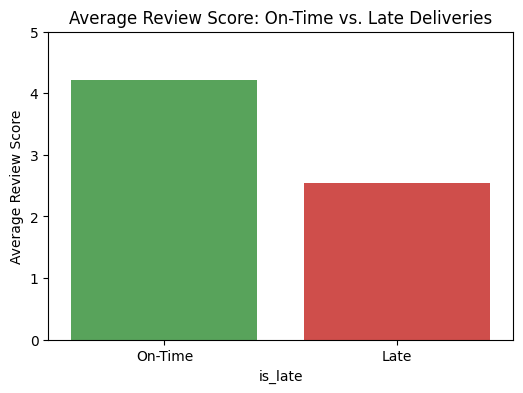

In [108]:
avg_scores = delivered_orders.groupby('is_late')['review_score'].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=avg_scores.index, y=avg_scores.values, hue=avg_scores.index, palette=['#4CAF50', '#E53935'], legend=False)
plt.xticks([0, 1], ['On-Time', 'Late'])
plt.ylabel('Average Review Score')
plt.title('Average Review Score: On-Time vs. Late Deliveries')
plt.ylim(0, 5)
plt.show()

This graph clearly shows that review scores are affected by late deliveries: the average score for late deliveries is around 2.5, while on-time deliveries average around 4.2.

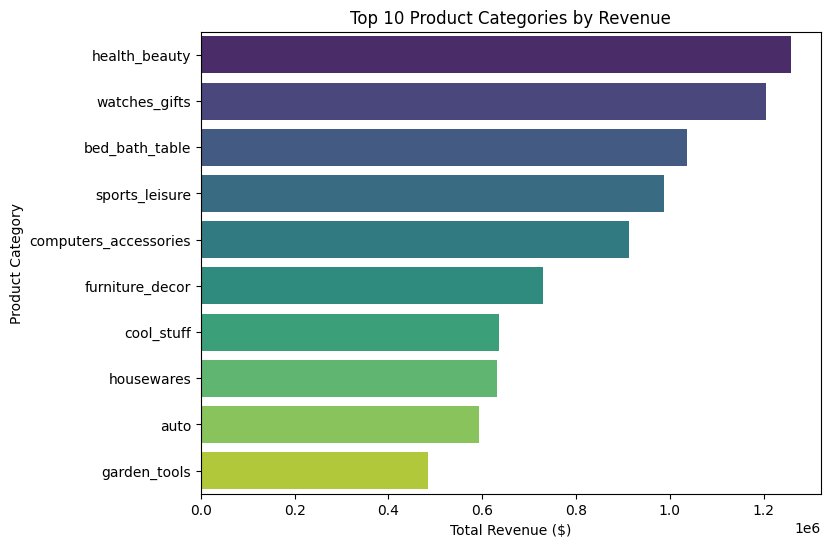

In [109]:
top_categories = revenue_df.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, hue=top_categories.index, palette='viridis', legend=False)
plt.xlabel('Total Revenue ($)')
plt.ylabel('Product Category')
plt.title('Top 10 Product Categories by Revenue')
plt.show()

As seen in our analysis, the product category `health_beauty` has the highest revenue among all of the top 10 product categories by revenue.

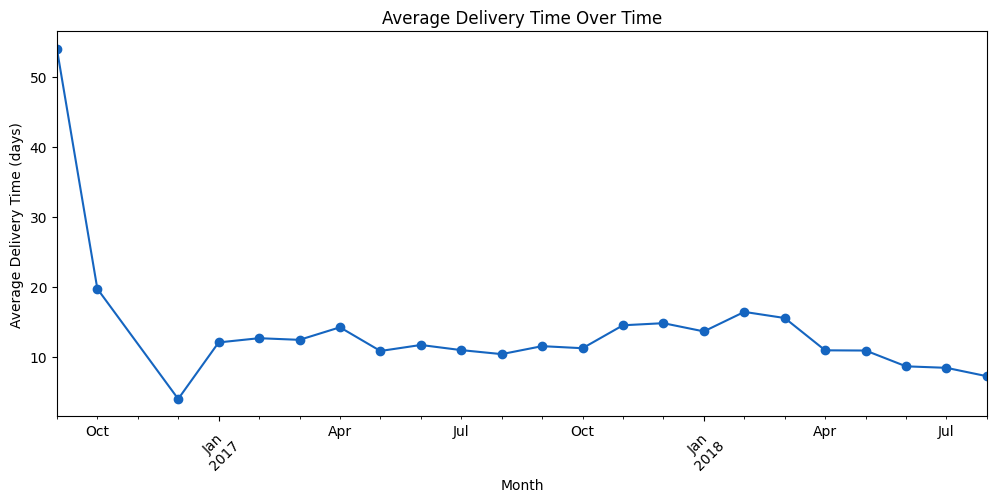

In [110]:
delivered_orders['purchase_month'] = delivered_orders['order_purchase_timestamp'].dt.to_period('M')

monthly_delivery = delivered_orders.groupby('purchase_month')['delivery_time_days'].mean()

plt.figure(figsize=(12, 5))
monthly_delivery.plot(kind='line', marker='o', color='#1565C0')
plt.xlabel('Month')
plt.ylabel('Average Delivery Time (days)')
plt.title('Average Delivery Time Over Time')
plt.xticks(rotation=45)
plt.show()

In [111]:
delivered_orders.groupby('purchase_month').size().head(5)

purchase_month
2016-09       3
2016-10     336
2016-12       1
2017-01     963
2017-02    1962
Freq: M, dtype: int64

The highest average delivery time occurs in the platform's earliest month (~54 days). This was confirmed to coincide with extremely low order volume: September 2016 had just 3 delivered orders, and December 2016 had only 1, meaning a small number of slow early orders could easily skew the average, rather than reflecting a systemic delivery problem. After this initial spike, delivery times drop sharply and then fluctuate in a relatively stable range (roughly 10-16 days) through most of 2017, before showing a gradual improvement trend heading into 2018.

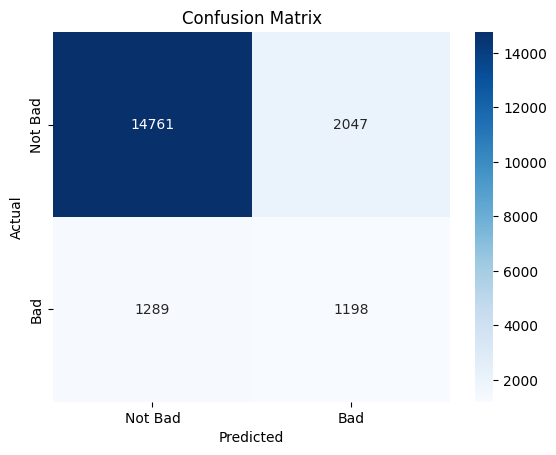

In [112]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Bad', 'Bad'], yticklabels=['Not Bad', 'Bad'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Confusion matrix for the balanced model, visualized as a heatmap, 1,197 of 2,487 actual bad reviews correctly caught, consistent with the ~48% recall discussed earlier.

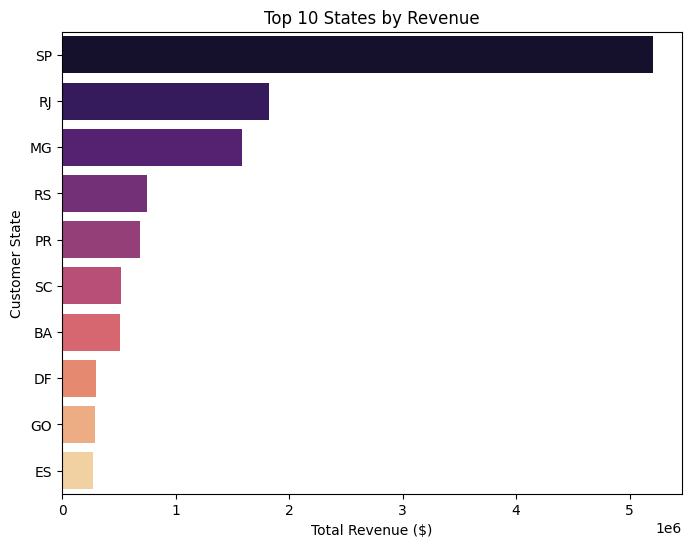

In [113]:
top_states = revenue_df.groupby('customer_state')['price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_states.values, y=top_states.index, hue=top_states.index, palette='magma', legend=False)
plt.xlabel('Total Revenue ($)')
plt.ylabel('Customer State')
plt.title('Top 10 States by Revenue')
plt.show()

As seen before in our analysis, SP, RJ, and MJ remain the top 3 states in terms of revenue. 

# Conclusion

### 1. Data Entry Issues

Several data inconsistencies surfaced during cleaning that point to underlying data entry issues rather than genuine business events. Some orders marked "delivered" had no recorded delivery date, while a small number marked "canceled" had a complete delivery timeline. When we checked the reviews for these canceled-but-delivered orders, the comments didn't consistently support a straightforward "returned after a bad experience" explanation; some were positive, one was unrelated to the seller entirely, and several customers explicitly claimed non-delivery despite a delivery date being logged. This suggests some status labels and dates in Olist's system may be recorded inaccurately, which is worth flagging as a data quality issue on Olist's end rather than a pattern that can be fully explained by customer behavior alone.

### 2. Payment splitting / cross-product effect

We observed cases where a single order was paid for using an unusually high number of small, separate payments; one order alone was split across 63 individual voucher transactions. Beyond the analytical complexity this caused (requiring careful deduplication to avoid inflating revenue and order counts), this pattern likely has real operational costs for Olist: processing dozens of small transactions per order adds overhead and increases the chance of data inconsistencies, similar to the "canceled but delivered" discrepancies found above. A reasonable limit on the number of payment splits per order could reduce this overhead and improve data reliability.

### 3. Late delivery and seller accountability

Our hypothesis test confirmed that late deliveries are strongly associated with lower review scores (average 2.54 vs. 4.21 for on-time orders), and this difference is statistically significant and not due to chance. When we examined this at the seller level, we found that late deliveries are widespread across many sellers, not isolated to a few outliers. This raises an important question for Olist: is late delivery primarily a seller-side issue (e.g., slow order preparation), or a platform/logistics-side issue (e.g., carrier delays, unrealistic estimated delivery windows)? Distinguishing between these would determine whether the right intervention is holding individual sellers accountable or addressing systemic logistics and delivery-estimate issues at the platform level.

### 4. Customer retention limitation

Repeat customers make up only about 3% of the customer base, yet contribute roughly 5.6% of total revenue; a modest but real sign that returning customers spend somewhat more than one-time buyers. Given the dataset covers Olist's early years (2016-2018), including a very low-volume launch period in late 2016, this retention rate may understate what a more mature version of the platform could achieve. A key limitation is that this analysis only reflects that specific window in time; it's unclear whether retention patterns have improved, worsened, or stayed consistent in the years since.

### 5. Classification model limitations

The classification model for predicting bad reviews reached 89% accuracy but only 25% recall on actual bad reviews, meaning it missed most of the cases it was built to catch. This wasn't primarily a data volume issue (the model was trained on nearly 100,000 orders), but rather a combination of factors: bad reviews are a minority class, making the model naturally biased toward the majority outcome; some features (like `is_late`) are only known around the same time the outcome occurs, limiting their true predictive value; and a simple logistic regression may not capture more complex, non-linear relationships in the data. Future improvements could include techniques like class rebalancing (which we tested, improving recall to 48% at the cost of precision), more predictive pre-purchase features, and trying more powerful models like Random Forest or XGBoost.